In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("../data/cleaned_churn.csv")

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29,29,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56,1889,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,53,108,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,42,1840,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70,151,1,0,0,0,1,0,1,0


In [4]:
df['AvgSpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [5]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend
0,0,0,1,0,1,0,0,0,1,0,...,29,0,0,0,0,1,0,0,0,14.500000
1,1,0,0,0,34,1,0,1,0,1,...,1889,0,1,0,0,0,1,0,0,53.971429
2,1,0,0,0,2,1,0,1,1,0,...,108,1,0,0,0,0,1,0,0,36.000000
3,1,0,0,0,45,0,0,1,0,1,...,1840,0,1,0,0,0,0,0,0,40.000000
4,0,0,0,0,2,1,0,0,0,0,...,151,1,0,0,0,1,0,1,0,50.333333


In [6]:
df['TenureGroup'] = pd.cut(df['tenure'],
                          bins=[0,12,24,48,72],
                          labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [7]:
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4-6yr
0,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,14.500000,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,53.971429,False,True,False
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,1,0,0,36.000000,False,False,False
3,1,0,0,0,45,0,0,1,0,1,...,0,0,0,0,0,0,40.000000,False,True,False
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,0,1,0,50.333333,False,False,False


In [9]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,AvgSpend,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4-6yr
0,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,14.500000,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,53.971429,0,1,0
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,1,0,0,36.000000,0,0,0
3,1,0,0,0,45,0,0,1,0,1,...,0,0,0,0,0,0,40.000000,0,1,0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,0,1,0,50.333333,0,0,0


<Axes: >

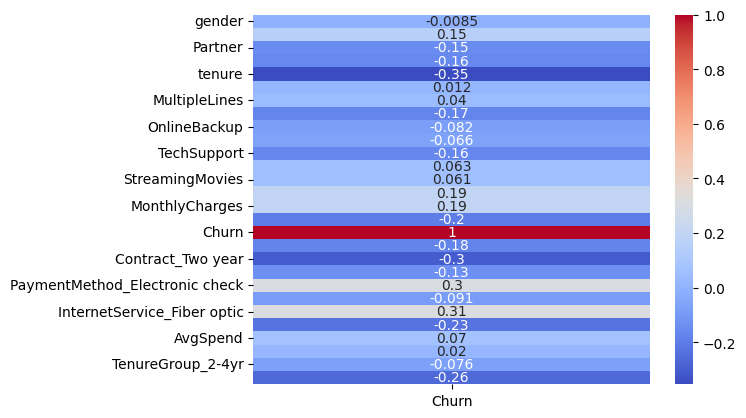

In [11]:
sns.heatmap(df.select_dtypes(include='number').corr()[['Churn']], annot=True, cmap='coolwarm')

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1033
           1       0.56      0.48      0.52       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.75      1407



In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [17]:
print(importance.head(50))

                                  Feature  Importance
21            InternetService_Fiber optic    0.388550
17                      Contract_Two year    0.159942
22                     InternetService_No    0.113667
16                      Contract_One year    0.084841
4                                  tenure    0.023768
12                        StreamingMovies    0.020769
6                           MultipleLines    0.015732
7                          OnlineSecurity    0.013537
5                            PhoneService    0.013450
19         PaymentMethod_Electronic check    0.012224
10                            TechSupport    0.011816
11                            StreamingTV    0.011479
8                            OnlineBackup    0.011322
14                         MonthlyCharges    0.011162
1                           SeniorCitizen    0.011090
24                      TenureGroup_1-2yr    0.010089
3                              Dependents    0.009871
15                          

In [18]:
import shap

c:\Users\rohan\OneDrive\Desktop\Telco Customer Churn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


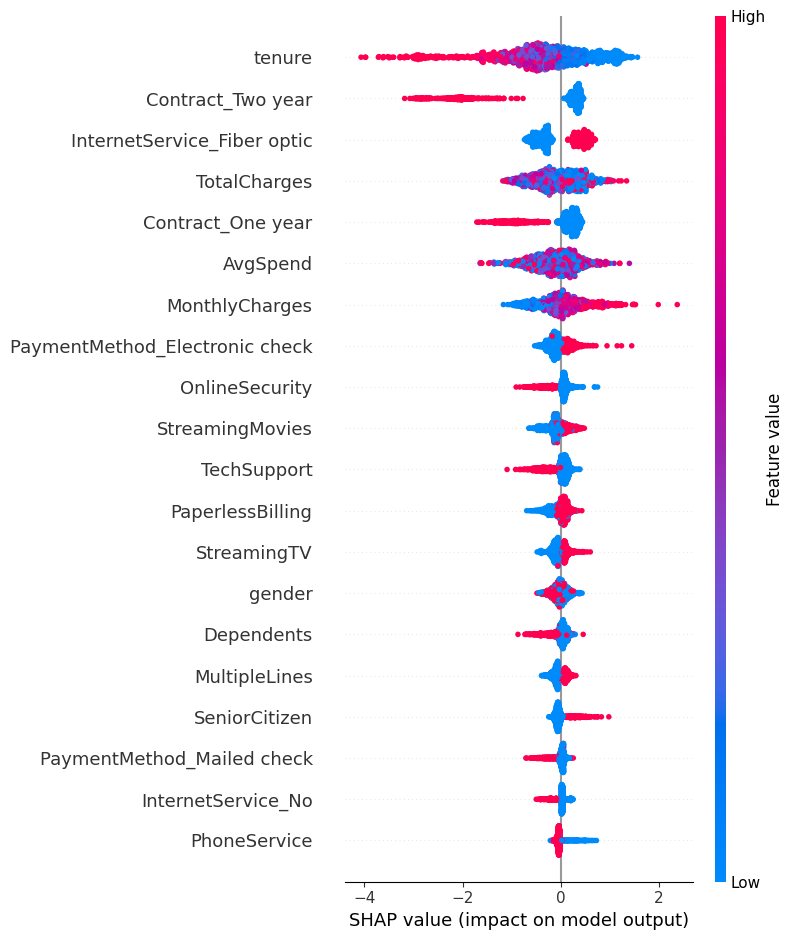

In [19]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [20]:

df['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [21]:
model = XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
)

###number of non-churn / number of churn
Example (your data)

Let’s say:

Non-churn = 5000
Churn = 1800

5000 / 1800 ≈ 2.7

scale_pos_weight = 2.7
1 churn mistake = 2.7 times more serious

In [22]:
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1033
           1       0.53      0.64      0.58       374

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.75      0.76      1407



In [25]:
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.69      0.78      1033
           1       0.47      0.78      0.59       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.73      1407



In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(15))

                           Feature  Importance
17               Contract_Two year    0.339799
21     InternetService_Fiber optic    0.171206
16               Contract_One year    0.120387
22              InternetService_No    0.115435
12                 StreamingMovies    0.030981
5                     PhoneService    0.016665
4                           tenure    0.016636
19  PaymentMethod_Electronic check    0.012317
6                    MultipleLines    0.012074
7                   OnlineSecurity    0.011711
10                     TechSupport    0.011517
14                  MonthlyCharges    0.011158
15                    TotalCharges    0.010857
11                     StreamingTV    0.010719
13                PaperlessBilling    0.010656


In [28]:
new_customer = pd.DataFrame({
    'gender': [1],
    'SeniorCitizen': [0],
    'Partner': [0],
    'Dependents': [0],
    'tenure': [2],
    'PhoneService': [1],
    'MultipleLines': [0],
    'OnlineSecurity': [0],
    'OnlineBackup': [0],
    'DeviceProtection': [0],
    'TechSupport': [0],
    'StreamingTV': [1],
    'StreamingMovies': [1],
    'PaperlessBilling': [1],
    'MonthlyCharges': [95],
    'TotalCharges': [180],
    'AvgSpend': [60],

    'Contract_One year': [0],
    'Contract_Two year': [0],

    'PaymentMethod_Credit card (automatic)': [0],
    'PaymentMethod_Electronic check': [1],
    'PaymentMethod_Mailed check': [0],

    'InternetService_Fiber optic': [1],
    'InternetService_No': [0],

    'TenureGroup_1-2yr': [0],
    'TenureGroup_2-4yr': [0],
    'TenureGroup_4-6yr': [0]
})

In [29]:
new_customer = new_customer[X.columns]

In [30]:
prediction = model.predict(new_customer)

print(prediction)

[1]


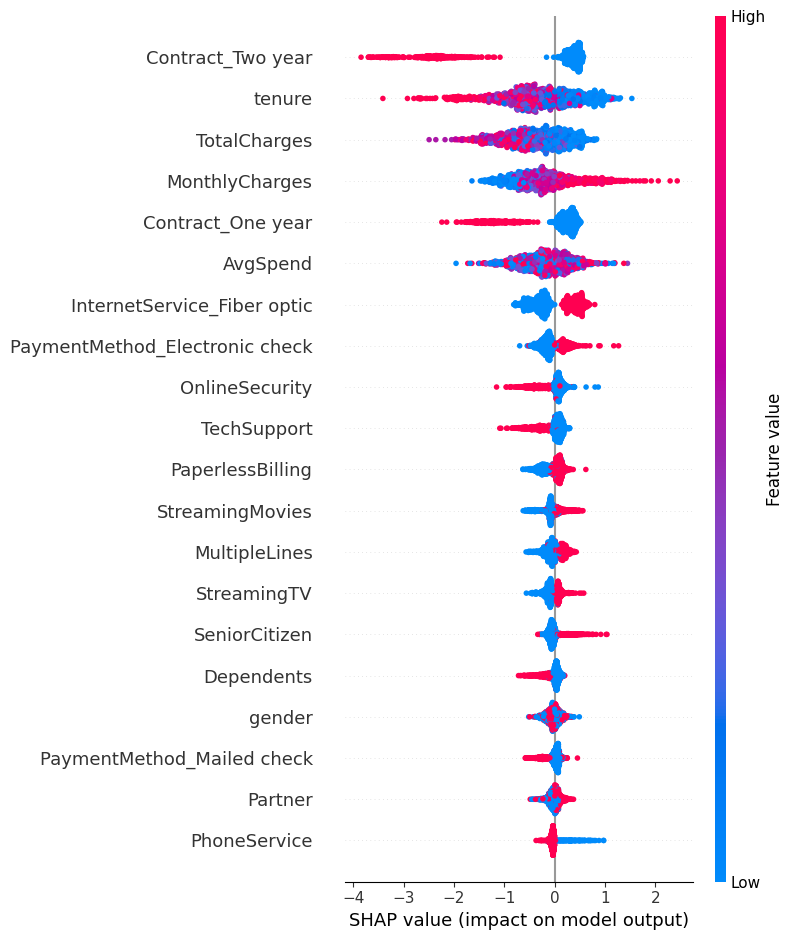

In [31]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)